# Advanced PyTorch Custom Components

This notebook covers **PyTorch implementations** of Part 2 concepts from the assignment.

**Topics covered:**
- **Custom Learning Rate Scheduler**: Warmup, cosine annealing, cyclical LR
- **Custom Loss Functions**: Focal loss, label smoothing, contrastive loss
- **Custom Activation Functions**: Mish, Swish, GELU, learnable activations
- **Custom Layers**: Attention, residual blocks, squeeze-excitation
- **Custom Optimizer**: SGD with momentum, Adam from scratch
- **Custom Training Loop**: Manual forward/backward, gradient clipping, mixed precision

**Framework:** PyTorch

**Dataset:** Fashion MNIST

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import math
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}, Device: {device}")

PyTorch: 2.10.0+cu128, Device: cuda


In [2]:
# Load Fashion MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, transform=transform)

# Split train into train/val
train_data, val_data = torch.utils.data.random_split(train_dataset, [55000, 5000])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 265kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.9MB/s]


---
## Part 1: Custom Learning Rate Schedulers

In [3]:
class WarmupCosineScheduler:
    """Learning rate scheduler with linear warmup and cosine decay."""

    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr
        self.base_lrs = [group['lr'] for group in optimizer.param_groups]
        self.current_step = 0

    def step(self):
        self.current_step += 1

        if self.current_step <= self.warmup_steps:
            # Linear warmup
            scale = self.current_step / self.warmup_steps
        else:
            # Cosine decay
            progress = (self.current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            scale = 0.5 * (1 + math.cos(math.pi * progress))

        for param_group, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            param_group['lr'] = max(base_lr * scale, self.min_lr)

    def get_lr(self):
        return [group['lr'] for group in self.optimizer.param_groups]

In [4]:
class CyclicalLR:
    """Cyclical learning rate scheduler."""

    def __init__(self, optimizer, min_lr, max_lr, step_size):
        self.optimizer = optimizer
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.current_step = 0

    def step(self):
        self.current_step += 1
        cycle = math.floor(1 + self.current_step / (2 * self.step_size))
        x = abs(self.current_step / self.step_size - 2 * cycle + 1)
        lr = self.min_lr + (self.max_lr - self.min_lr) * max(0, 1 - x)

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def get_lr(self):
        return [group['lr'] for group in self.optimizer.param_groups]

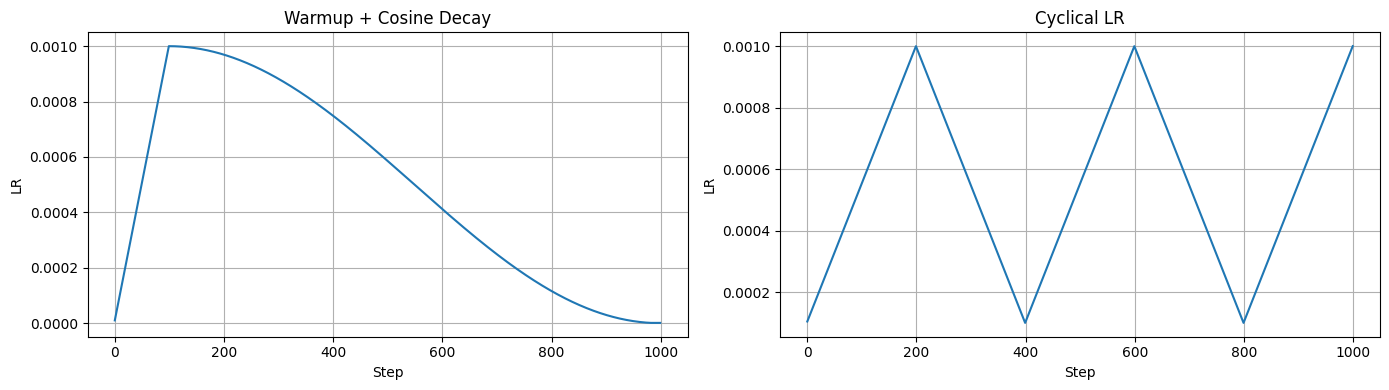

In [5]:
# Visualize schedulers
dummy_model = nn.Linear(10, 10)
dummy_opt = optim.SGD(dummy_model.parameters(), lr=0.001)

warmup_scheduler = WarmupCosineScheduler(dummy_opt, warmup_steps=100, total_steps=1000)
warmup_lrs = []
for _ in range(1000):
    warmup_scheduler.step()
    warmup_lrs.append(warmup_scheduler.get_lr()[0])

dummy_opt2 = optim.SGD(dummy_model.parameters(), lr=0.001)
cyclic_scheduler = CyclicalLR(dummy_opt2, min_lr=0.0001, max_lr=0.001, step_size=200)
cyclic_lrs = []
for _ in range(1000):
    cyclic_scheduler.step()
    cyclic_lrs.append(cyclic_scheduler.get_lr()[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(warmup_lrs)
axes[0].set_title('Warmup + Cosine Decay')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('LR')
axes[0].grid(True)

axes[1].plot(cyclic_lrs)
axes[1].set_title('Cyclical LR')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('LR')
axes[1].grid(True)
plt.tight_layout()
plt.show()

---
## Part 2: Custom Loss Functions

In [6]:
class FocalLoss(nn.Module):
    """Focal loss for handling class imbalance."""

    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [7]:
class LabelSmoothingLoss(nn.Module):
    """Cross-entropy loss with label smoothing."""

    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=-1)

        # Create smooth labels
        with torch.no_grad():
            smooth_labels = torch.full_like(log_probs, self.smoothing / (self.num_classes - 1))
            smooth_labels.scatter_(1, targets.unsqueeze(1), self.confidence)

        loss = (-smooth_labels * log_probs).sum(dim=-1)
        return loss.mean()

In [8]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss for siamese networks."""

    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # label: 1 if same class, 0 if different
        distance = F.pairwise_distance(output1, output2)
        loss = label * distance.pow(2) + (1 - label) * F.relu(self.margin - distance).pow(2)
        return loss.mean()

---
## Part 3: Custom Activation Functions

In [9]:
class Mish(nn.Module):
    """Mish activation: x * tanh(softplus(x))."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class Swish(nn.Module):
    """Swish activation: x * sigmoid(x)."""
    def forward(self, x):
        return x * torch.sigmoid(x)

class GELU(nn.Module):
    """Gaussian Error Linear Unit."""
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x.pow(3))))

In [10]:
class ParametricSwish(nn.Module):
    """Learnable Swish with trainable beta parameter."""

    def __init__(self):
        super().__init__()
        self.beta = nn.Parameter(torch.ones(1))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

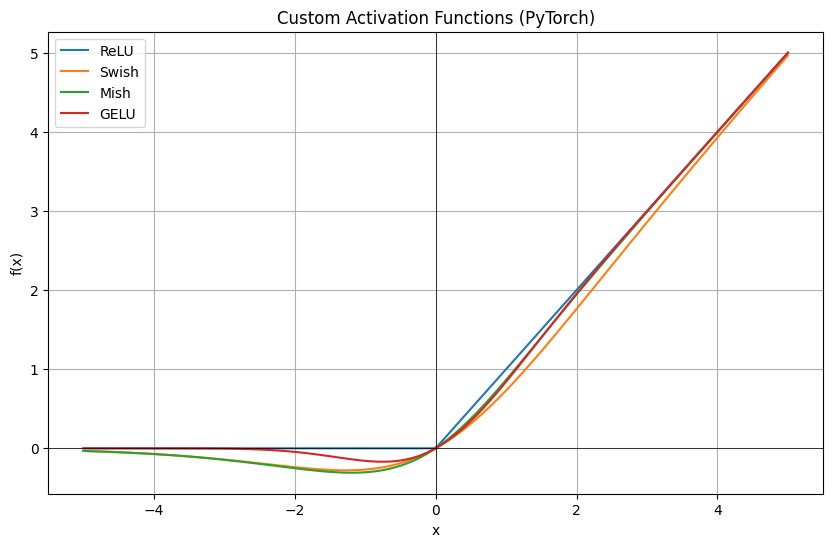

In [11]:
# Visualize activations
x = torch.linspace(-5, 5, 200)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x.numpy(), F.relu(x).numpy(), label='ReLU')
ax.plot(x.numpy(), Swish()(x).detach().numpy(), label='Swish')
ax.plot(x.numpy(), Mish()(x).detach().numpy(), label='Mish')
ax.plot(x.numpy(), GELU()(x).detach().numpy(), label='GELU')
ax.set_title('Custom Activation Functions (PyTorch)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
ax.grid(True)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.show()

---
## Part 4: Custom Layers

In [12]:
class SelfAttention(nn.Module):
    """Self-attention layer."""

    def __init__(self, embed_dim, num_heads=1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # Compute attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)

        # Apply attention to values
        out = torch.matmul(attn_weights, v)
        return self.out_proj(out)

In [13]:
class ResidualBlock(nn.Module):
    """Residual block with skip connection."""

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

In [14]:
class SqueezeExcitation(nn.Module):
    """Squeeze-and-Excitation block for channel attention."""

    def __init__(self, channels, ratio=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // ratio, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // ratio, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        squeeze = self.squeeze(x).view(b, c)
        excitation = self.excitation(squeeze).view(b, c, 1, 1)
        return x * excitation

In [15]:
class SpatialDropout2d(nn.Module):
    """Spatial dropout - drops entire feature maps."""

    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0:
            return x

        # Create mask for channels
        mask = torch.bernoulli(torch.ones(x.shape[0], x.shape[1], 1, 1, device=x.device) * (1 - self.p))
        return x * mask / (1 - self.p)

---
## Part 5: Custom Optimizers

In [16]:
class CustomSGD:
    """SGD with momentum from scratch."""

    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        with torch.no_grad():
            for p, v in zip(self.params, self.velocities):
                if p.grad is None:
                    continue
                v.mul_(self.momentum).add_(p.grad)
                p.sub_(self.lr * v)

In [17]:
class CustomAdam:
    """Adam optimizer from scratch."""

    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.t = 0

        # First and second moment estimates
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        self.t += 1

        with torch.no_grad():
            for p, m, v in zip(self.params, self.m, self.v):
                if p.grad is None:
                    continue

                g = p.grad

                # Update biased first moment estimate
                m.mul_(self.beta1).add_(g, alpha=1 - self.beta1)
                # Update biased second moment estimate
                v.mul_(self.beta2).addcmul_(g, g, value=1 - self.beta2)

                # Bias correction
                m_hat = m / (1 - self.beta1 ** self.t)
                v_hat = v / (1 - self.beta2 ** self.t)

                # Update parameters
                p.sub_(self.lr * m_hat / (v_hat.sqrt() + self.eps))

In [18]:
class AdamW:
    """Adam with decoupled weight decay."""

    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0

        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        self.t += 1

        with torch.no_grad():
            for p, m, v in zip(self.params, self.m, self.v):
                if p.grad is None:
                    continue

                g = p.grad

                m.mul_(self.beta1).add_(g, alpha=1 - self.beta1)
                v.mul_(self.beta2).addcmul_(g, g, value=1 - self.beta2)

                m_hat = m / (1 - self.beta1 ** self.t)
                v_hat = v / (1 - self.beta2 ** self.t)

                # Adam update + decoupled weight decay
                p.sub_(self.lr * (m_hat / (v_hat.sqrt() + self.eps) + self.weight_decay * p))

---
## Part 6: Custom Model with All Components

In [19]:
class CustomCNN(nn.Module):
    """Custom CNN with all custom components."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Initial conv
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Residual blocks with SE
        self.res1 = ResidualBlock(32, 64)
        self.se1 = SqueezeExcitation(64, ratio=8)
        self.pool1 = nn.MaxPool2d(2)

        self.res2 = ResidualBlock(64, 128)
        self.se2 = SqueezeExcitation(128, ratio=8)
        self.pool2 = nn.MaxPool2d(2)

        # Custom layers
        self.spatial_dropout = SpatialDropout2d(0.25)

        # Classification head
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(128, 64)
        self.activation = ParametricSwish()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.res1(x)
        x = self.se1(x)
        x = self.pool1(x)

        x = self.res2(x)
        x = self.se2(x)
        x = self.pool2(x)

        x = self.spatial_dropout(x)

        x = self.gap(x).view(x.size(0), -1)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

---
## Part 7: Custom Training Loop

In [20]:
class Trainer:
    """Advanced trainer with gradient clipping and mixed precision."""

    def __init__(self, model, optimizer, loss_fn, device, clip_norm=None, use_amp=False):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device
        self.clip_norm = clip_norm
        self.use_amp = use_amp

        if use_amp:
            self.scaler = torch.cuda.amp.GradScaler()

        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(self.device), y.to(self.device)

            self.optimizer.zero_grad()

            if self.use_amp:
                with torch.cuda.amp.autocast():
                    outputs = self.model(x)
                    loss = self.loss_fn(outputs, y)

                self.scaler.scale(loss).backward()

                if self.clip_norm:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_norm)

                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(x)
                loss = self.loss_fn(outputs, y)
                loss.backward()

                if self.clip_norm:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_norm)

                self.optimizer.step()

            total_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, val_loader):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0

        for x, y in val_loader:
            x, y = x.to(self.device), y.to(self.device)
            outputs = self.model(x)
            loss = self.loss_fn(outputs, y)

            total_loss += loss.item() * x.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)

        return total_loss / total, correct / total

    def fit(self, train_loader, val_loader, epochs, scheduler=None):
        for epoch in range(epochs):
            start_time = time.time()

            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)

            if scheduler:
                scheduler.step()

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            epoch_time = time.time() - start_time
            print(f"Epoch {epoch+1}/{epochs} - {epoch_time:.2f}s - "
                  f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
                  f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        return self.history

In [21]:
# Train with all custom components
model = CustomCNN(num_classes=10)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = FocalLoss(gamma=2.0)

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    clip_norm=1.0
)

print("Training Custom CNN with Focal Loss...\n")
history = trainer.fit(train_loader, val_loader, epochs=10)

Training Custom CNN with Focal Loss...

Epoch 1/10 - 19.95s - loss: 0.3675 - acc: 0.7473 - val_loss: 0.2599 - val_acc: 0.8010
Epoch 2/10 - 18.58s - loss: 0.1896 - acc: 0.8495 - val_loss: 0.1706 - val_acc: 0.8636
Epoch 3/10 - 18.35s - loss: 0.1512 - acc: 0.8747 - val_loss: 0.1418 - val_acc: 0.8894
Epoch 4/10 - 17.98s - loss: 0.1330 - acc: 0.8864 - val_loss: 0.1196 - val_acc: 0.8974
Epoch 5/10 - 17.93s - loss: 0.1164 - acc: 0.9004 - val_loss: 0.1681 - val_acc: 0.8708
Epoch 6/10 - 18.04s - loss: 0.1066 - acc: 0.9051 - val_loss: 0.1007 - val_acc: 0.9168
Epoch 7/10 - 18.11s - loss: 0.0981 - acc: 0.9105 - val_loss: 0.1573 - val_acc: 0.8790
Epoch 8/10 - 17.90s - loss: 0.0912 - acc: 0.9169 - val_loss: 0.1198 - val_acc: 0.9028
Epoch 9/10 - 17.91s - loss: 0.0832 - acc: 0.9227 - val_loss: 0.0895 - val_acc: 0.9256
Epoch 10/10 - 17.80s - loss: 0.0780 - acc: 0.9257 - val_loss: 0.0923 - val_acc: 0.9236


In [22]:
# Evaluate on test set
test_loss, test_acc = trainer.evaluate(test_loader)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


Test Loss: 0.1028, Test Accuracy: 0.9162


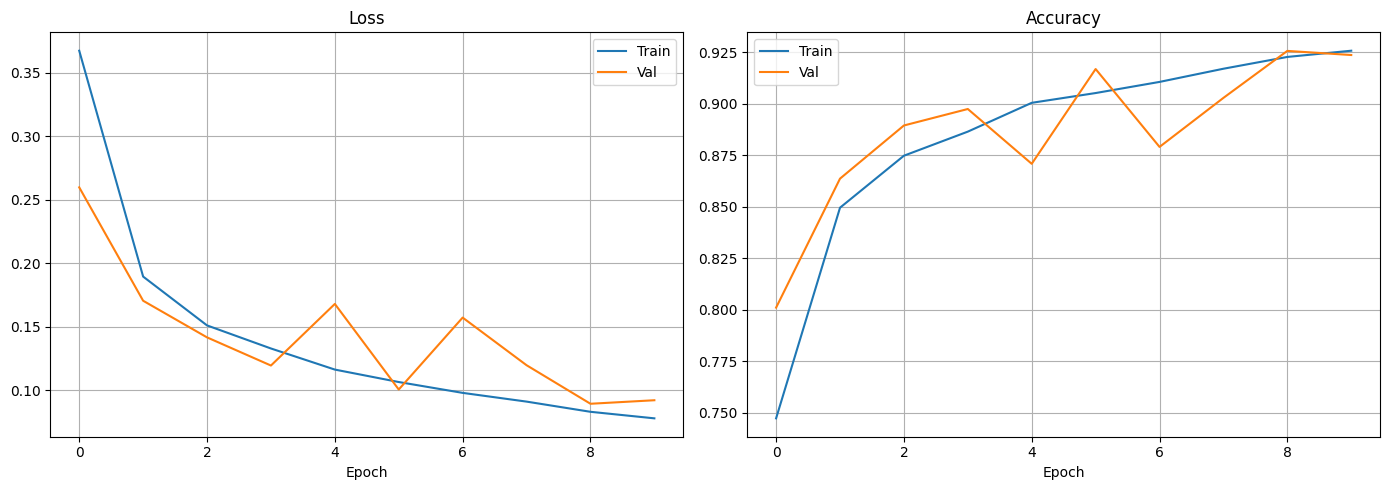

In [23]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Summary

| Component | PyTorch Implementation | Key Features |
|-----------|----------------------|---------------|
| **WarmupCosineScheduler** | Custom class | Linear warmup + cosine decay |
| **CyclicalLR** | Custom class | Triangular cycling |
| **FocalLoss** | nn.Module | Down-weight easy samples |
| **LabelSmoothingLoss** | nn.Module | Soft labels |
| **Mish/Swish/GELU** | nn.Module | Smooth activations |
| **SelfAttention** | nn.Module | Q/K/V projections |
| **ResidualBlock** | nn.Module | Skip connections |
| **SqueezeExcitation** | nn.Module | Channel attention |
| **CustomSGD/Adam** | Custom class | Manual optimization |
| **Trainer** | Custom class | Gradient clipping, AMP |